In [13]:
"""
EXERCICE 1 : Du GLM au ML — Fréquence sinistre auto (freMTPL2freq)
================================================================
Objectif : Comparer une approche statistique (GLM Poisson) et une approche ML 
(Decision Tree) sur un problème de fréquence sinistre.

Ce que vous allez apprendre :
- Charger un dataset actuariel dans scikit-learn
- Préparer les données pour la modélisation
- Calibrer un GLM Poisson et un arbre de décision
- Comparer les approches avec une métrique adaptée

Temps estimé : 15 minutes
"""

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.linear_model import PoissonRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance
import matplotlib.pyplot as plt

# =============================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================
# Le dataset freMTPL2freq est disponible directement sur OpenML
# C'est le même dataset que celui utilisé dans le tutoriel scikit-learn :
# https://scikit-learn.org/stable/auto_examples/linear_model/plot_poisson_regression_non_normal_loss.html

print("Chargement des données freMTPL2freq...")
# df = fetch_openml(data_id=41214, as_frame=True).frame
df = pd.read_csv("freMTPL2freq.csv")  # Charger depuis le CSV local (si téléchargé)
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\nColonnes disponibles : {list(df.columns)}")
print(f"\nAperçu :")
print(df.head())


Chargement des données freMTPL2freq...
Dataset chargé : 678013 lignes, 12 colonnes

Colonnes disponibles : ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']

Aperçu :
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand   VehGas  Density Region  
0      B12  Regular     1217    R82  
1      B12  Regular     1217    R82  
2      B12   Diesel       54    R22  
3      B12   Diesel       76    R72  
4      B12   Diesel       76    R72  


In [ ]:
# =============================================================
# 2. PRÉPARATION DES DONNÉES
# =============================================================
# En actuariat, on modélise la FRÉQUENCE = Nombre de sinistres / Exposition

# TODO : Sélectionner les features numériques pertinentes
features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density']

# TODO : Créer la target (fréquence)
# Attention : on modélise le NOMBRE de sinistres avec un offset d'exposition
# Avec PoissonRegressor de sklearn, on peut passer sample_weight = Exposure
X = df[features].astype(float)
y = df['ClaimNb'].astype(float)
exposure = df['Exposure'].astype(float)

# Fréquence observée (pour information)
print(f"\nFréquence moyenne observée : {y.sum() / exposure.sum():.4f}")
print(f"Nombre moyen de sinistres : {y.mean():.4f}")



Fréquence moyenne observée : 0.1007
Nombre moyen de sinistres : 0.0532


In [ ]:
# =============================================================
# 3. SÉPARATION TRAIN / TEST
# =============================================================
X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X, y, exposure, test_size=0.3, random_state=42
)
print(f"\nTrain : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")



Train : 474609 observations
Test  : 203404 observations


In [ ]:
from sklearn.preprocessing import normalize

# Normalisation des features pour comparaison
X_train = normalize(X_train)
X_test = normalize(X_test)

,DrivAge,BonusMalus,VehAge,Density
566452,33.0,60.0,14.0,71.0
160831,54.0,50.0,6.0,821.0
626694,21.0,90.0,0.0,2399.0
218427,45.0,50.0,9.0,10.0
51959,52.0,54.0,0.0,415.0
...,...,...,...,...
259178,57.0,85.0,6.0,879.0
365838,46.0,56.0,10.0,1609.0
131932,35.0,50.0,8.0,3744.0
671155,32.0,54.0,1.0,6485.0


In [ ]:
# =============================================================
# 4. MODÈLE 1 : GLM POISSON (approche statistique)
# =============================================================
# PoissonRegressor dans sklearn = GLM Poisson avec lien log
# C'est l'exact équivalent de ce que vous feriez en R avec glm(family=poisson)

glm = PoissonRegressor(alpha=0, max_iter=1000)  # alpha=0 = pas de régularisation
glm.fit(X_train, y_train, sample_weight=exp_train)

y_pred_glm = glm.predict(X_test)
print(f"\n--- GLM Poisson ---")
print(f"Coefficients : {dict(zip(features, glm.coef_))}")
print(f"Intercept : {glm.intercept_:.4f}")


--- GLM Poisson ---
Coefficients : {'DrivAge': np.float64(-0.5297240124066847), 'BonusMalus': np.float64(0.14946982771320763), 'VehAge': np.float64(-3.7630956756379206), 'Density': np.float64(-0.5998603380466723)}
Intercept : -2.0280


In [26]:
# =============================================================
# 5. MODÈLE 2 : ARBRE DE DÉCISION (approche ML)
# =============================================================
# Un arbre de décision ne fait aucune hypothèse distributionnelle

# 5a. Arbre peu profond (conservateur)
tree_shallow = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_shallow.fit(X_train, y_train / exp_train, sample_weight=exp_train)
y_pred_tree_shallow = tree_shallow.predict(X_test) * exp_test

# 5b. Arbre profond (agressif) — ATTENTION potentiel overfitting !
tree_deep = DecisionTreeRegressor(max_depth=None, random_state=42)
tree_deep.fit(X_train, y_train / exp_train, sample_weight=exp_train)
y_pred_tree_deep = tree_deep.predict(X_test) * exp_test



In [30]:
tree_deep.get_depth()

77

In [ ]:
# =============================================================
# 6. COMPARAISON DES PERFORMANCES
# =============================================================
# La Poisson Deviance est la métrique naturelle pour un problème de fréquence
# On calcule la deviance sur les fréquences prédites vs observées

freq_test = y_test / exp_test
freq_pred_glm = y_pred_glm / exp_test
freq_pred_tree_shallow = tree_shallow.predict(X_test)
freq_pred_tree_deep = tree_deep.predict(X_test)

# Attention : mean_poisson_deviance exige des prédictions > 0
freq_pred_glm = np.clip(freq_pred_glm, 1e-6, None)
freq_pred_tree_shallow = np.clip(freq_pred_tree_shallow, 1e-6, None)
freq_pred_tree_deep = np.clip(freq_pred_tree_deep, 1e-6, None)

dev_glm = mean_poisson_deviance(freq_test, freq_pred_glm, sample_weight=exp_test)
dev_tree_shallow = mean_poisson_deviance(freq_test, freq_pred_tree_shallow, sample_weight=exp_test)
dev_tree_deep = mean_poisson_deviance(freq_test, freq_pred_tree_deep, sample_weight=exp_test)

print(f"\n{'='*50}")
print(f"COMPARAISON — Poisson Deviance (plus bas = mieux)")
print(f"{'='*50}")
print(f"GLM Poisson            : {dev_glm:.6f}")
print(f"Arbre (max_depth=4)    : {dev_tree_shallow:.6f}")
print(f"Arbre (max_depth=None) : {dev_tree_deep:.6f}")




COMPARAISON — Poisson Deviance (plus bas = mieux)
GLM Poisson            : 0.609755
Arbre (max_depth=4)    : 0.606585
Arbre (max_depth=None) : 2.629302


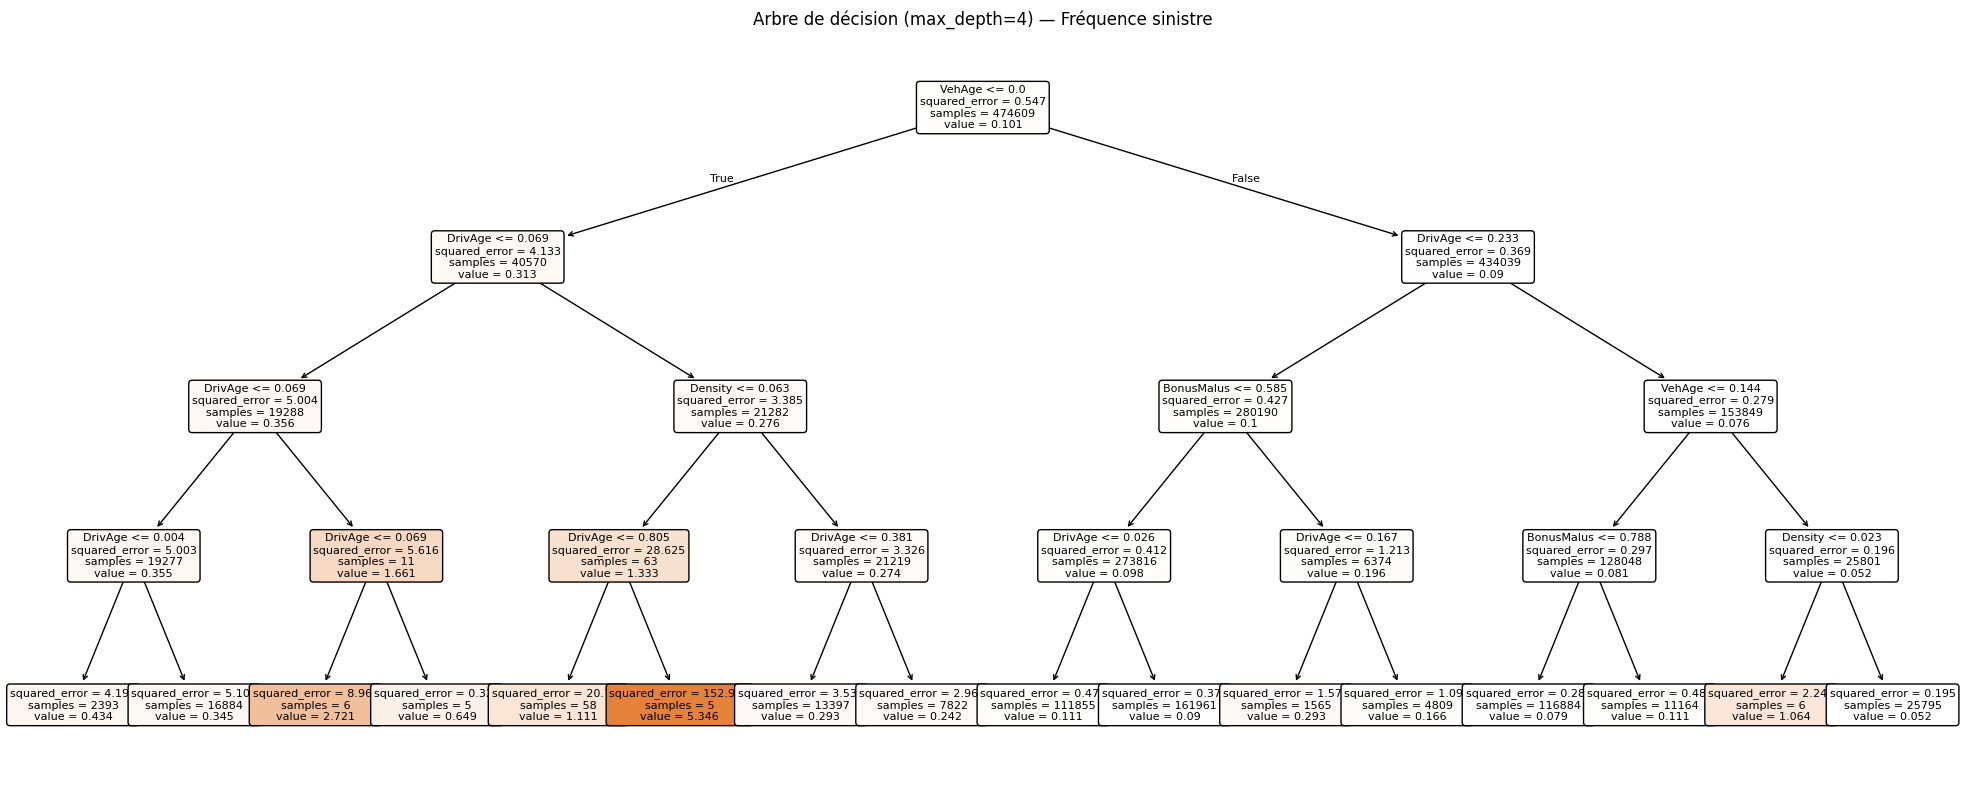

In [31]:
# =============================================================
# 7. VISUALISATION DE L'ARBRE (optionnel)
# =============================================================
plt.figure(figsize=(20, 8))
plot_tree(tree_shallow, feature_names=features, filled=True, rounded=True, fontsize=8)
plt.title("Arbre de décision (max_depth=4) — Fréquence sinistre")
plt.tight_layout()
plt.savefig("arbre_frequence.png", dpi=150)
plt.show()



In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Quel modèle généralise le mieux sur le test set ? Pourquoi ?
2. L'arbre profond (max_depth=None) est-il meilleur ou pire que l'arbre 
   contraint ? Que vous dit cela sur l'overfitting ?
3. Le GLM donne des coefficients interprétables. Que dit le coefficient 
   du BonusMalus ? Est-ce cohérent avec votre intuition ?
4. L'arbre de décision ne fait aucune hypothèse sur la distribution de Y.
   Est-ce un avantage ou un inconvénient dans ce contexte ?
5. En pratique, pourquoi un actuaire utiliserait-il les deux approches 
   de manière complémentaire ?
   """

"\n1. Quel modèle généralise le mieux sur le test set ? Pourquoi ?\n2. L'arbre profond (max_depth=None) est-il meilleur ou pire que l'arbre \n   contraint ? Que vous dit cela sur l'overfitting ?\n3. Le GLM donne des coefficients interprétables. Que dit le coefficient \n   du BonusMalus ? Est-ce cohérent avec votre intuition ?\n4. L'arbre de décision ne fait aucune hypothèse sur la distribution de Y.\n   Est-ce un avantage ou un inconvénient dans ce contexte ?\n5. En pratique, pourquoi un actuaire utiliserait-il les deux approches \n   de manière complémentaire ?\n   "